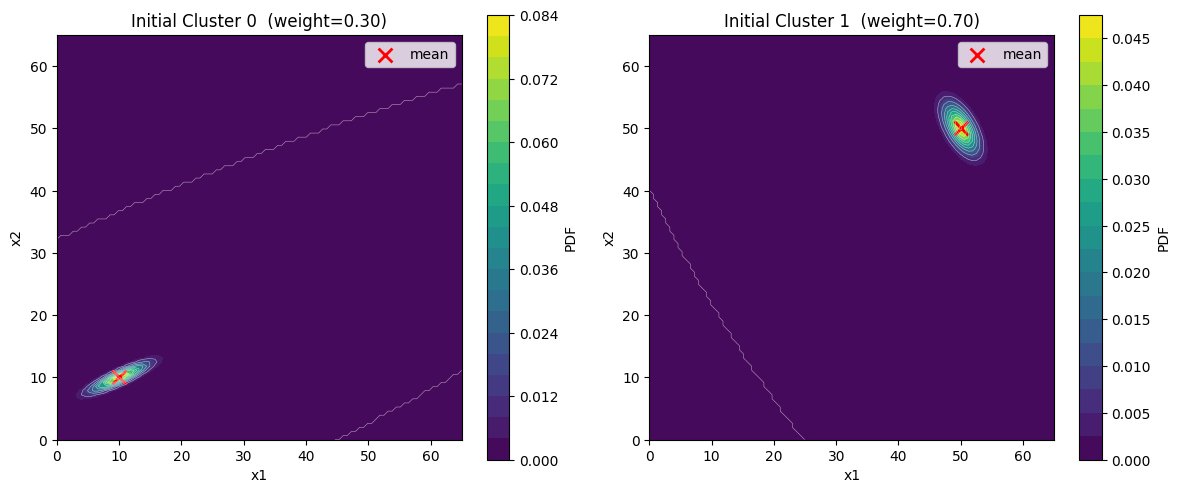

Processing noisy data stream...
🚨 Time Step 081 -> ⚠️ ALARM: Abrupt jump from Cluster 1 to Cluster 2! (P(C1_prev)=1.00 -> P(C2_curr)=1.00)


In [9]:
import numpy as np
from GMM import *
import matplotlib.pyplot as plt
import numpy as np

def generate_noisy_time_varying_stream(num_steps=150, noise_level=0.5):
    """
    Generates a realistic stream of data points with intentional 
    measurement noise, gradual drift, and sudden state shocks.
    """
    np.random.seed(42) # For reproducible testing
    stream = []
    true_labels = []
    
    # Base states
    c1_base = np.array([10.0, 10.0])
    c2_base = np.array([50.0, 50.0])
    
    for t in range(1, num_steps + 1):
        # Phase 1: Stationary Cluster 1 with measurement noise
        if t <= 30:
            point = c1_base + np.random.normal(0, noise_level, size=2)
            label = 0
            
        # Phase 2: Gradual Concept Drift (C1 slowly migrates towards the right)
        elif 30 < t <= 80:
            drift_factor = (t - 30) / 50.0  # Scales smoothly from 0.0 to 1.0
            current_c1_center = c1_base + np.array([15.0 * drift_factor, 2.0 * drift_factor])
            point = current_c1_center + np.random.normal(0, noise_level, size=2)
            label = 0
            
        # Phase 3: The Abrupt Structural Shock (Sudden leap to Cluster 2)
        elif t == 81:
            point = c2_base + np.random.normal(0, noise_level, size=2)
            label = 1
            
        # Phase 4: Stationary Cluster 2 with periodic noise shocks
        else:
            # Introduce an occasional extreme noise spike (anomaly) at step 120
            current_noise = noise_level * 3.0 if t == 120 else noise_level
            point = c2_base + np.random.normal(0, current_noise, size=2)
            label = 1
            
        stream.append(point)
        true_labels.append(label)
        
    return np.array(stream), true_labels

# --- Execution Example ---
# Generate a noisy stream
noisy_data, labels = generate_noisy_time_varying_stream(num_steps=150, noise_level=0.8)

# Initialize our standard streaming tracker from previous steps
# (Assuming StreamingGMMAlarm class is loaded)
tracker = StreamingGMMAlarm(
    means=np.array([[10.0, 10.0], [50.0, 50.0]]),
    covariances=np.array([
        [[8.0, 3.5], [3.5, 2.0]],   # Elongated ellipse (orientation 1)
        [[3.0, -2.5], [-2.5, 6.0]]  # Elongated ellipse (different orientation)
    ]),
    weights=np.array([0.3, 0.7]),
    forgetting_factor=0.97 # Slightly higher memory to resist noise spikes
)

def plot_cluster_densities(gmm, xlim=(0, 65), ylim=(0, 65), n_points=100, title_prefix=""):
    """Plot 2D Gaussian PDF contours for each GMM cluster."""
    xx, yy = np.meshgrid(
        np.linspace(xlim[0], xlim[1], n_points),
        np.linspace(ylim[0], ylim[1], n_points),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    fig, axes = plt.subplots(1, gmm.K, figsize=(6 * gmm.K, 5))
    if gmm.K == 1:
        axes = [axes]

    for k in range(gmm.K):
        z = np.array([
            gmm._gaussian_likelihood(grid[i], gmm.mu[k], gmm.sigma[k])
            for i in range(len(grid))
        ]).reshape(xx.shape)

        ax = axes[k]
        cf = ax.contourf(xx, yy, z, levels=20, cmap="viridis")
        ax.contour(xx, yy, z, levels=10, colors="white", linewidths=0.4, alpha=0.6)
        ax.scatter(
            gmm.mu[k, 0], gmm.mu[k, 1],
            c="red", marker="x", s=100, linewidths=2, label="mean",
        )
        ax.set_title(f"{title_prefix}Cluster {k}  (weight={gmm.weights[k]:.2f})")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_aspect("equal")
        ax.legend(loc="upper right")
        plt.colorbar(cf, ax=ax, label="PDF")

    plt.tight_layout()
    plt.show()

plot_cluster_densities(tracker, title_prefix="Initial ")

# Feed the noisy stream into the tracker
print("Processing noisy data stream...")
for step, pt in enumerate(noisy_data, start=1):
    probs, alarm, msg = tracker.process_point(pt)
    if alarm:
        print(f"🚨 Time Step {step:03d} -> {msg}")

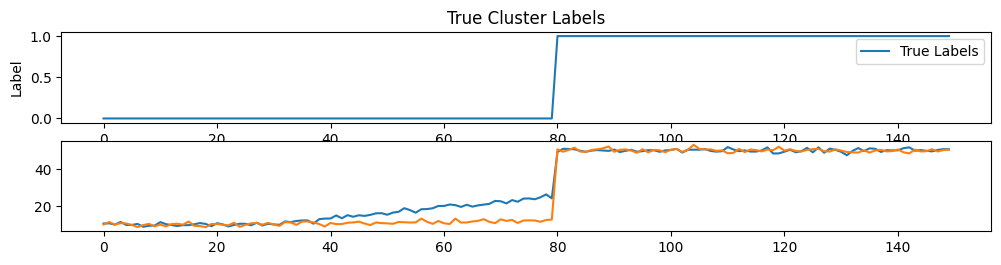

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(3,1,1)
plt.plot(labels, label='True Labels')
plt.title('True Cluster Labels')
plt.ylabel('Label')
plt.legend()

plt.subplot(3,1,2)
plt.plot(noisy_data)